In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier, plot_importance

In [2]:
# import drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
# Load the CSV
df = pd.read_csv("/content/drive/My Drive/capstone_data/ml_data/ml_data_monthly.csv")

# drop precip
df = df.drop(columns=['precip'])

# Choose years manually
train_years = [1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003,
               2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013,
               2014, 2015, 2016, 2017, 2018, 2019, 2020]

test_years = [2021, 2022, 2023, 2024]

# Manual split
train_df = df[df['year'].isin(train_years)]
test_df = df[df['year'].isin(test_years)]

# Separate Features and labels
X_train = train_df.drop(columns=['year', 'tercile'])
X_test = test_df.drop(columns=['year', 'tercile'])
y_train = train_df['tercile']
y_test = test_df['tercile']

# Encode labels (an: 1 0 0, bn: 0 0 1, n: 0 1 0)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Define model
model = XGBClassifier(eval_metric='mlogloss')

# Train the model on Training data and training labels
model.fit(X_train, y_train_enc)

# Predict classes
y_pred = model.predict(X_test)

# Predict probabilities for each class
y_proba = model.predict_proba(X_test)

In [24]:
# Classification report
print("=== Classification Report ===")
print(classification_report(
    y_test_enc,
    y_pred,
    labels=[0, 1, 2],  # Ensure all label indices are present
    target_names=le.classes_,
    zero_division=0  # Handle division by zero
))

=== Classification Report ===
              precision    recall  f1-score   support

          an       1.00      0.50      0.67         6
          bn       0.67      1.00      0.80         6
           n       0.00      0.00      0.00         0

    accuracy                           0.75        12
   macro avg       0.56      0.50      0.49        12
weighted avg       0.83      0.75      0.73        12



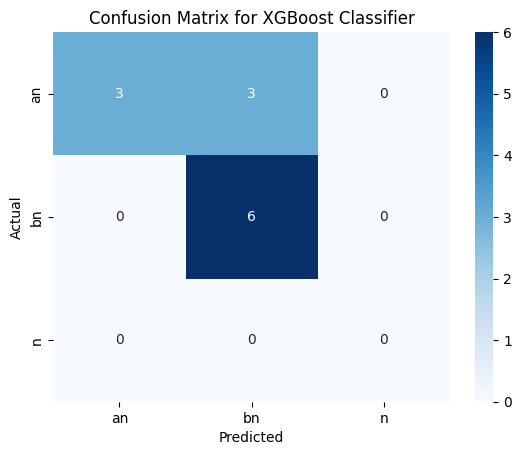

In [21]:
# Confusion matrix
conf_mat = confusion_matrix(y_test_enc, y_pred, labels=[0, 1, 2])
sns.heatmap(conf_mat, annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for XGBoost Classifier')
plt.show()

We see that the model never predicted N, and the test data also never had an N tercile for the years 2021-2024 for the MAM season. The model misclassified AN as BN 3 times, but correctly classified all BN years. Thus, the model may be biased towards BN observations, and this may be due to our predictors being biased towards BN.


<Figure size 1000x600 with 0 Axes>

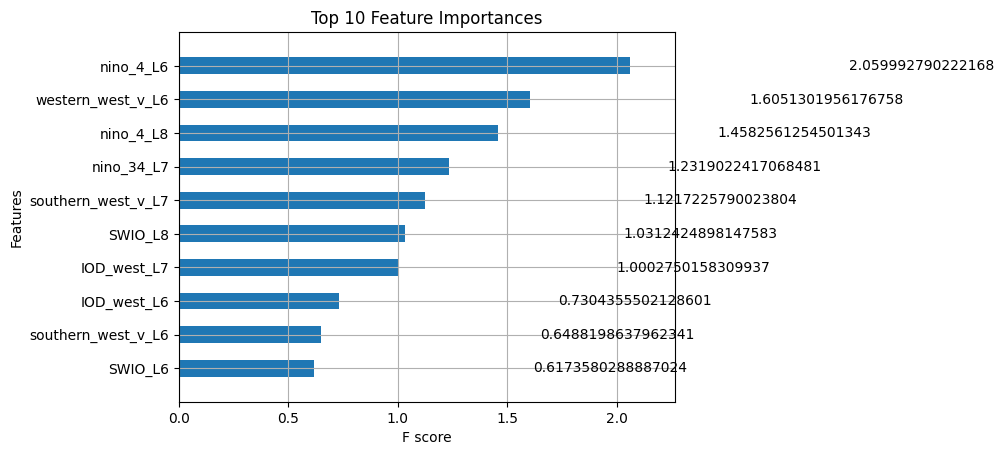

In [22]:
# Feature importance plot
plt.figure(figsize=(10, 6))
plot_importance(model, max_num_features=10, importance_type='gain', height=0.5)
plt.title("Top 10 Feature Importances")
plt.show()

In [23]:
# Reset index to ensure alignment
test_info = test_df[['year', 'month']].reset_index(drop=True)
proba_df = pd.DataFrame(y_proba, columns=[f"proba_{cls}" for cls in le.classes_])

# Concatenate year, month, and predicted probabilities
results_df = pd.concat([test_info, proba_df], axis=1)

# Optional: add predicted and true class labels
results_df['true_label'] = le.inverse_transform(y_test_enc)
results_df['predicted_label'] = le.inverse_transform(y_pred)

# Print full DataFrame
print("=== Predictions with Probabilities ===")
print(results_df.to_string(index=False))

=== Predictions with Probabilities ===
 year  month  proba_an  proba_bn  proba_n true_label predicted_label
 2021      3  0.189832  0.640627 0.169541         bn              bn
 2021      4  0.226946  0.624855 0.148200         bn              bn
 2021      5  0.240103  0.510868 0.249029         bn              bn
 2022      3  0.048745  0.746476 0.204779         bn              bn
 2022      4  0.051818  0.722758 0.225424         bn              bn
 2022      5  0.079392  0.722237 0.198371         bn              bn
 2023      3  0.059467  0.536606 0.403927         an              bn
 2023      4  0.061821  0.557850 0.380329         an              bn
 2023      5  0.041575  0.552007 0.406418         an              bn
 2024      3  0.843826  0.098357 0.057818         an              an
 2024      4  0.847933  0.093833 0.058234         an              an
 2024      5  0.750489  0.082888 0.166623         an              an


Here we can see what probability of tercile category the model predicted for each year and each month in the testing data.